# Fine-tune MedGemma 4B-IT trên IU X-Ray (Open-I)

Fine-tuning MedGemma-4B-IT với QLoRA cho task sinh báo cáo X-quang ngực.

**Dataset**: [ykumards/open-i](https://huggingface.co/datasets/ykumards/open-i) — 3,851 mẫu, tải miễn phí từ HuggingFace.

**Output**: `merged_model/` (~8-10GB) — model hoàn chỉnh, chạy offline.

---

| Cell | Bước | Thời gian |
|------|------|-----------|
| 1 | Kiểm tra GPU | ~5 giây |
| 2 | Cài thư viện | ~2-3 phút |
| 3 | Đăng nhập HuggingFace | ~30 giây |
| 4 | Mount Google Drive | ~10 giây |
| 5 | Cấu hình đường dẫn | ~1 giây |
| 6 | Tải dataset từ HuggingFace | ~3-5 phút |
| 7 | Chuẩn bị data → JSONL | ~2-3 phút |
| 8 | Cấu hình training | ~1 giây |
| 9 | **Training QLoRA** | ~1-3 giờ |
| 10 | Đánh giá (BLEU, ROUGE) | ~10-20 phút |
| 11 | **Merge → model hoàn chỉnh** | ~5-10 phút |
| 12 | Test inference | ~1 phút |

---
## Cell 1: Kiểm tra GPU

Nếu không thấy GPU → **Runtime > Change runtime type > T4 GPU**.

In [ ]:
!nvidia-smi

import torch
print(f"\nPyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_mem / 1024**3:.1f} GB")

---
## Cell 2: Cài đặt thư viện

In [ ]:
!pip install -q \
    torch \
    "transformers>=4.45.0" \
    "accelerate>=0.34.0" \
    "peft>=0.13.0" \
    "bitsandbytes>=0.44.0" \
    "trl>=0.12.0" \
    datasets pandas rouge-score nltk pillow tqdm scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 55.6 MB/s eta 0:00:00


---
## Cell 3: Đăng nhập HuggingFace

Cần để tải model `google/medgemma-4b-it`.

**Trước khi chạy**:
1. Vào https://huggingface.co/google/medgemma-4b-it → nhấn **Agree and access repository**
2. Tạo token tại https://huggingface.co/settings/tokens

In [ ]:
from huggingface_hub import login
login()

---
## Cell 4: Mount Google Drive

Lưu data và model trên Drive để không mất khi Colab disconnect.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---
## Cell 5: Cấu hình đường dẫn

In [ ]:
import os

DATA_DIR = "/content/drive/MyDrive/iu_xray_data"
IMAGE_DIR = f"{DATA_DIR}/images"
PROCESSED_DIR = f"{DATA_DIR}/processed"
OUTPUT_DIR = "/content/drive/MyDrive/medgemma_output"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Data:   {DATA_DIR}")
print(f"Images: {IMAGE_DIR}")
print(f"Output: {OUTPUT_DIR}")

Data:   /content/drive/MyDrive/iu_xray_data
Images: /content/drive/MyDrive/iu_xray_data/images
Output: /content/drive/MyDrive/medgemma_output


---
## Cell 6: Tải dataset từ HuggingFace

Dataset [ykumards/open-i](https://huggingface.co/datasets/ykumards/open-i) chứa 3,851 mẫu.

Mỗi mẫu có:
- `img_frontal` — ảnh X-quang frontal (bytes)
- `img_lateral` — ảnh X-quang lateral (bytes)
- `findings` — mô tả phát hiện
- `impression` — kết luận chẩn đoán


Chỉ cần chạy 1 lần. Nếu đã tải rồi, cell sẽ dùng cache.

In [ ]:
from datasets import load_dataset

ds = load_dataset("ykumards/open-i", split="train")

print(f"Total samples: {len(ds)}")
print(f"Columns: {ds.column_names}")
print(f"\nExample:")
print(f"  uid: {ds[0]['uid']}")
print(f"  findings: {str(ds[0]['findings'])[:100]}...")
print(f"  impression: {str(ds[0]['impression'])[:100]}...")
print(f"  img_frontal: {'Yes' if ds[0]['img_frontal'] else 'No'}")
print(f"  img_lateral: {'Yes' if ds[0]['img_lateral'] else 'No'}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00005-c80629f6027d8e(…):   0%|          | 0.00/425M [00:00<?, ?B/s]

data/train-00001-of-00005-07e6c158a3f561(…):   0%|          | 0.00/418M [00:00<?, ?B/s]

data/train-00002-of-00005-653f05c8b15c22(…):   0%|          | 0.00/416M [00:00<?, ?B/s]

data/train-00003-of-00005-1d66a487a8489b(…):   0%|          | 0.00/416M [00:00<?, ?B/s]

data/train-00004-of-00005-208b7d689f1c7b(…):   0%|          | 0.00/421M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3851 [00:00<?, ? examples/s]

Total samples: 3851
Columns: ['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression', 'img_frontal', 'img_lateral']

Example:
  uid: 1
  findings: The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. T...
  impression: Normal chest x-XXXX....
  img_frontal: Yes
  img_lateral: Yes


---
## Cell 7: Chuẩn bị data → JSONL

**Quá trình**:
1. Lọc mẫu có `img_frontal` (bỏ mẫu chỉ có lateral)
2. Lọc mẫu có findings hoặc impression (bỏ mẫu trống)
3. Lưu ảnh frontal ra file PNG
4. Ghép findings + impression thành báo cáo
5. Chia train (80%) / validate (10%) / test (10%)
6. Lưu JSONL

In [ ]:

!rm -rf {IMAGE_DIR}
os.makedirs(IMAGE_DIR, exist_ok=True)

In [ ]:
import json, os
from sklearn.model_selection import train_test_split
from tqdm import tqdm

samples = []
skipped = 0

for row in tqdm(ds, desc="Processing"):
    if not row["img_frontal"]:
        skipped += 1
        continue

    findings = str(row.get("findings") or "").strip()
    impression = str(row.get("impression") or "").strip()

    if findings in ("", "None", "nan") and impression in ("", "None", "nan"):
        skipped += 1
        continue

    parts = []
    if findings and findings not in ("None", "nan"):
        parts.append(f"FINDINGS: {findings}")
    if impression and impression not in ("None", "nan"):
        parts.append(f"IMPRESSION: {impression}")
    report = "\n".join(parts)

    uid = row["uid"]
    img_path = os.path.join(IMAGE_DIR, f"{uid}_frontal.jpg")

    if not os.path.isfile(img_path):
        try:
            with open(img_path, "wb") as f:
                f.write(row["img_frontal"])
        except Exception as e:
            print(f"  Skip uid {uid}: {e}")
            skipped += 1
            continue

    samples.append({"image_path": img_path, "report": report})

print(f"\nValid: {len(samples)}, Skipped: {skipped}")

# Chia train / val / test (80/10/10)
train_val, test = train_test_split(samples, test_size=0.1, random_state=42)
train, val = train_test_split(train_val, test_size=0.111, random_state=42)

for split_name, split_data in [("train", train), ("validate", val), ("test", test)]:
    path = f"{PROCESSED_DIR}/{split_name}.jsonl"
    with open(path, "w") as f:
        for s in split_data:
            f.write(json.dumps(s, ensure_ascii=False) + "\n")
    print(f"  {split_name}: {len(split_data)} samples")


Processing: 100%|██████████| 3851/3851 [00:01<00:00, 2134.12it/s]



Valid: 3666, Skipped: 185
  train: 2932 samples
  validate: 367 samples
  test: 367 samples


---
## Cell 8: Cấu hình training

| Tham số | Giá trị | Ý nghĩa |
|---------|---------|----------|
| `EPOCHS` | 3 | Số vòng train |
| `LR` | 2e-4 | Tốc độ học |
| `GRAD_ACCUM` | 8 | Effective batch = 8 |
| `MAX_LENGTH` | 512 | Giới hạn token |
| `LORA_R` | 16 | LoRA rank |

In [ ]:

MODEL_ID = "google/medgemma-4b-it"

EPOCHS = 3
BATCH_SIZE = 4
LR = 2e-4
GRAD_ACCUM = 4
MAX_LENGTH = 768
LORA_R = 32
LORA_ALPHA = 64

PROMPT = "Describe the findings in this chest X-ray image and provide a clinical impression."

import torch
if torch.cuda.get_device_capability()[0] >= 8:
    COMPUTE_DTYPE = torch.bfloat16
    USE_BF16, USE_FP16 = True, False
else:
    COMPUTE_DTYPE = torch.float16
    USE_BF16, USE_FP16 = False, True

print(f"Model:      {MODEL_ID}")
print(f"GPU:        {torch.cuda.get_device_name(0)}")
print(f"VRAM:       {torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB")
print(f"Precision:  {'BF16' if USE_BF16 else 'FP16'}")
print(f"LoRA r:     {LORA_R}")
print(f"Batch:      {BATCH_SIZE} × {GRAD_ACCUM} = {BATCH_SIZE * GRAD_ACCUM} effective")
print(f"Max tokens: {MAX_LENGTH}")
print(f"Epochs:     {EPOCHS}")

Model:      google/medgemma-4b-it
GPU:        NVIDIA A100-SXM4-40GB
VRAM:       42 GB
Precision:  BF16
LoRA r:     32
Batch:      4 × 4 = 16 effective
Max tokens: 768
Epochs:     3


---
## Cell 9: TRAINING

**Đây là cell chính** — chiếm phần lớn thời gian.

**Quá trình bên trong**:
1. Load MedGemma 4B ở 4-bit → ~3GB VRAM
2. Gắn QLoRA adapter vào q/k/v/o_proj → train ~0.15% tham số
3. Đóng băng vision encoder (SigLIP)
4. Tạo dataset: ảnh + prompt → model học sinh báo cáo
5. Train với HuggingFace Trainer
6. Lưu adapter


In [ ]:
import json, os, gc
import torch
from PIL import Image
from torch.utils.data import Dataset
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

# Giải phóng VRAM từ lần chạy trước (nếu có)
for var in ["model", "trainer"]:
    if var in dir():
        exec(f"del {var}")
gc.collect()
torch.cuda.empty_cache()
print(f"GPU free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB / {torch.cuda.mem_get_info()[1]/1e9:.1f} GB")


# ---- 1. Load processor ----
print("[1/5] Loading processor...")
processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token


# ---- 2. Load model 4-bit ----
print("[2/5] Loading model (4-bit)...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=COMPUTE_DTYPE,
    trust_remote_code=True,
)
print(f"  VRAM used: {torch.cuda.memory_allocated()/1e9:.1f} GB / {torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB")


# ---- 3. Apply QLoRA ----
print("[3/5] Applying QLoRA...")
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

for name, param in model.named_parameters():
    if "vision" in name.lower() or "siglip" in name.lower():
        param.requires_grad = False

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type=TaskType.CAUSAL_LM,
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


# ---- 4. Dataset ----
print("[4/5] Loading dataset...")

class IUXRayDataset(Dataset):
    def __init__(self, jsonl_path):
        self.samples = []
        with open(jsonl_path) as f:
            for line in f:
                if line.strip():
                    self.samples.append(json.loads(line))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        image = Image.open(s["image_path"]).convert("RGB")
        messages = [
            {"role": "user", "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": PROMPT},
            ]},
            {"role": "assistant", "content": [
                {"type": "text", "text": s["report"]},
            ]},
        ]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        enc = processor(text=text, images=[image], return_tensors="pt",
                        padding="max_length", truncation=True, max_length=MAX_LENGTH)

        input_ids = enc["input_ids"].squeeze(0)
        attn_mask = enc["attention_mask"].squeeze(0)
        pixel_vals = enc["pixel_values"].squeeze(0)
        token_type_ids = enc["token_type_ids"].squeeze(0) if "token_type_ids" in enc else torch.zeros_like(input_ids)
        labels = input_ids.clone()

        marker = processor.tokenizer.encode("model", add_special_tokens=False)
        seq = input_ids.tolist()
        mask_end = 0
        for i in range(len(seq) - len(marker) + 1):
            if seq[i:i+len(marker)] == marker:
                mask_end = i + len(marker)
                break
        labels[:mask_end] = -100
        labels[attn_mask == 0] = -100

        return {"input_ids": input_ids, "attention_mask": attn_mask,
                "pixel_values": pixel_vals, "token_type_ids": token_type_ids,
                "labels": labels}


def collate_fn(batch):
    return {k: torch.stack([x[k] for x in batch]) for k in batch[0]}


train_ds = IUXRayDataset(f"{PROCESSED_DIR}/train.jsonl")
val_ds = IUXRayDataset(f"{PROCESSED_DIR}/validate.jsonl")
print(f"  Train: {len(train_ds)}, Val: {len(val_ds)}")


# ---- 5. Train ----
print("[5/5] Starting training...")

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim="paged_adamw_8bit",
    logging_steps=10,
    save_steps=200,
    eval_strategy="steps",
    eval_steps=200,
    eval_accumulation_steps=4,
    save_total_limit=2,
    seed=42,
    bf16=USE_BF16,
    fp16=USE_FP16,
    dataloader_num_workers=4,
    dataloader_pin_memory=True,
    report_to="none",
    remove_unused_columns=False,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    max_grad_norm=1.0,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collate_fn,
)

trainer.train()

adapter_dir = f"{OUTPUT_DIR}/final_adapter"
model.save_pretrained(adapter_dir)
processor.save_pretrained(adapter_dir)
print(f"\nAdapter saved to {adapter_dir}")


GPU free: 36.0 GB / 42.4 GB
[1/5] Loading processor...
[2/5] Loading model (4-bit)...


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

  VRAM used: 6.0 GB / 42 GB
[3/5] Applying QLoRA...


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 23,797,760 || all params: 4,323,877,232 || trainable%: 0.5504
[4/5] Loading dataset...
  Train: 2932, Val: 367
[5/5] Starting training...


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss
200,0.834010,0.954656
400,0.718894,0.887188



Adapter saved to /content/drive/MyDrive/medgemma_output/final_adapter


---
## Cell 10: Đánh giá
Vẽ đồ thị train loss
Sinh báo cáo trên test set, tính BLEU-1..4 và ROUGE-L.

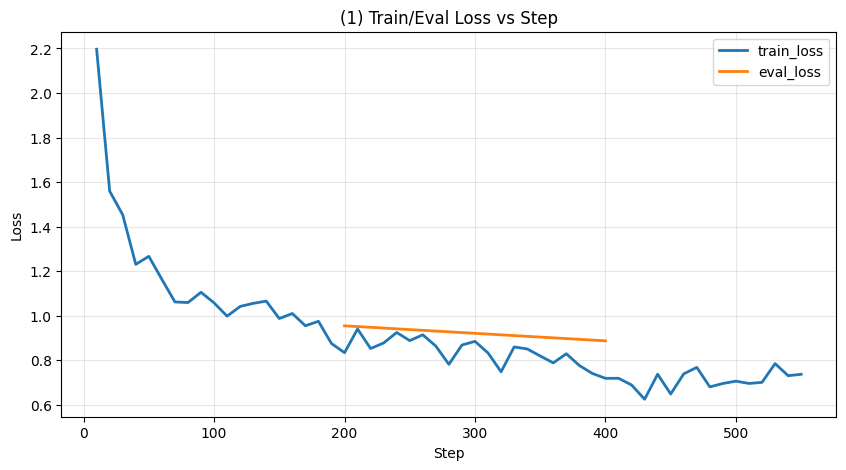

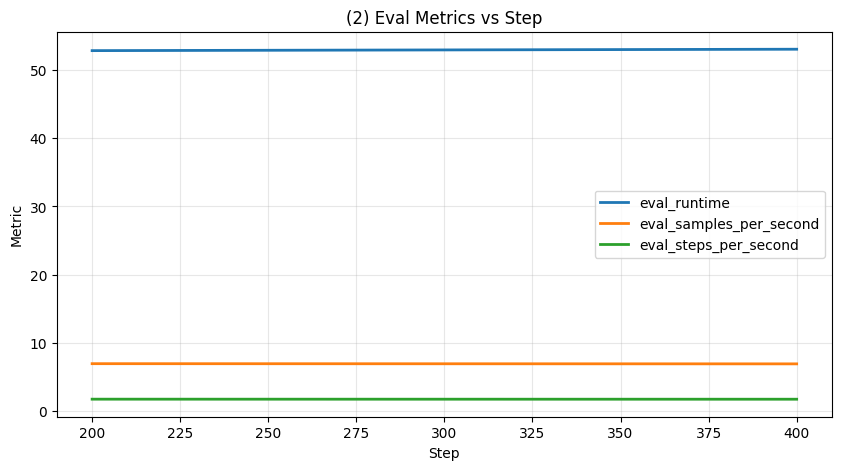


Last logs:


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
48,0.767993,1.120032,1.164405e-05,2.556617,470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,0.680424,0.961280,9.047892e-06,2.611187,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,0.695833,1.094788,6.765261e-06,2.665757,490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51,0.706251,0.979679,4.804029e-06,2.720327,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,0.695888,1.086536,3.170957e-06,2.774898,510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,0.700916,1.072141,1.871676e-06,2.829468,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54,0.785099,1.068817,9.106628e-07,2.884038,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55,0.730821,1.436729,2.912313e-07,2.938608,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,0.737088,1.098292,1.551649e-08,2.993179,550,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,NaN,NaN,NaN,3.000000,552,NaN,NaN,NaN,NaN,4353.4601,2.02,0.127,1.478568e+17,0.91499


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =============================
# Collect trainer log history
# =============================
if "trainer" not in globals():
    raise RuntimeError("Không tìm thấy biến `trainer`. Hãy chạy Cell TRAINING trước.")

log_history = getattr(getattr(trainer, "state", None), "log_history", None)
if not log_history:
    raise RuntimeError("trainer.state.log_history rỗng. Hãy chắc chắn TRAINING đã chạy và có log.")

logs = pd.DataFrame(log_history)
if "step" not in logs.columns:
    # fallback: tạo step giả nếu thiếu
    logs["step"] = range(1, len(logs) + 1)

# Tách train logs (có 'loss') và eval logs (có 'eval_loss')
train_logs = logs.dropna(subset=["loss"]).copy() if "loss" in logs.columns else pd.DataFrame()
eval_logs  = logs.dropna(subset=["eval_loss"]).copy() if "eval_loss" in logs.columns else pd.DataFrame()

# =============================
# Plot 1: Train/Eval loss curves
# =============================
plt.figure(figsize=(10, 5))
if not train_logs.empty:
    plt.plot(train_logs["step"], train_logs["loss"], label="train_loss", linewidth=2)
if not eval_logs.empty:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="eval_loss", linewidth=2)

plt.title("(1) Train/Eval Loss vs Step")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =============================
# Plot 2: Any eval_* metrics vs step
# =============================
# Lấy các cột eval_* (trừ eval_loss vì đã vẽ ở trên)
eval_metric_cols = [c for c in logs.columns if c.startswith("eval_") and c not in ("eval_loss",)]

if eval_logs.empty and not eval_metric_cols:
    print("Không có eval logs / eval_* metrics để vẽ đồ thị (2).")
else:
    # Nếu có eval_logs thì vẽ tất cả eval_* có trong eval_logs
    metric_cols_in_eval = [c for c in eval_metric_cols if c in eval_logs.columns and eval_logs[c].notna().any()]

    if not metric_cols_in_eval:
        # Vẽ learning_rate nếu có (thường có trong train logs)
        if "learning_rate" in logs.columns and logs["learning_rate"].notna().any():
            lr_logs = logs.dropna(subset=["learning_rate"]).copy()
            plt.figure(figsize=(10, 5))
            plt.plot(lr_logs["step"], lr_logs["learning_rate"], label="learning_rate", linewidth=2)
            plt.title("(2) Learning Rate vs Step")
            plt.xlabel("Step")
            plt.ylabel("Learning rate")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()
        else:
            print("Không có eval_* metric khác (ngoài eval_loss) và cũng không có learning_rate để vẽ đồ thị (2).")
    else:
        plt.figure(figsize=(10, 5))
        for c in metric_cols_in_eval:
            plt.plot(eval_logs["step"], eval_logs[c], label=c, linewidth=2)
        plt.title("(2) Eval Metrics vs Step")
        plt.xlabel("Step")
        plt.ylabel("Metric")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

# (Tuỳ chọn) xem nhanh 10 dòng log cuối
print("\nLast logs:")
display(logs.tail(10))

In [ ]:
import json
import nltk
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer

nltk.download("punkt_tab", quiet=True)
nltk.download("punkt", quiet=True)

# ─── Load test samples ───────────────────────────────────────────────────────
test_samples = []
with open(f"{PROCESSED_DIR}/test.jsonl") as f:
    for line in f:
        if line.strip():
            test_samples.append(json.loads(line))

print(f"Evaluating {len(test_samples)} test samples...")
model.eval()

# ─── Collect refs & hyps ─────────────────────────────────────────────────────
refs_all  = []   # list of list-of-tokens (corpus_bleu format)
hyps_all  = []   # list of tokens
rouge1_scores = []
rouge2_scores = []
rougeL_scores = []
skipped = 0

scorer_rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

for sample in tqdm(test_samples, desc="Evaluating"):
    ref = sample["report"]
    try:
        image = Image.open(sample["image_path"]).convert("RGB")
    except Exception:
        skipped += 1
        continue

    msgs = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text",  "text": PROMPT}
    ]}]
    text   = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=text, images=[image], return_tensors="pt").to(model.device)

    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=256, do_sample=False)

    hyp = processor.tokenizer.decode(
        out[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True
    ).strip()

    ref_tok = nltk.word_tokenize(ref.lower())
    hyp_tok = nltk.word_tokenize(hyp.lower())

    if not hyp_tok:          # model sinh ra chuỗi rỗng
        skipped += 1
        continue

    refs_all.append([ref_tok])   # corpus_bleu expects list-of-references per sentence
    hyps_all.append(hyp_tok)

    # ROUGE
    r = scorer_rouge.score(ref, hyp)
    rouge1_scores.append(r["rouge1"].fmeasure)
    rouge2_scores.append(r["rouge2"].fmeasure)
    rougeL_scores.append(r["rougeL"].fmeasure)

# ─── Corpus-level BLEU (chuẩn ACL) ──────────────────────────────────────────
smooth = SmoothingFunction().method1   # dùng cho corpus-level để tránh 0-count n-gram
bleu1 = corpus_bleu(refs_all, hyps_all, weights=(1, 0, 0, 0),           smoothing_function=smooth)
bleu2 = corpus_bleu(refs_all, hyps_all, weights=(0.5, 0.5, 0, 0),       smoothing_function=smooth)
bleu3 = corpus_bleu(refs_all, hyps_all, weights=(1/3, 1/3, 1/3, 0),     smoothing_function=smooth)
bleu4 = corpus_bleu(refs_all, hyps_all, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)

# ─── In kết quả ──────────────────────────────────────────────────────────────
print(f"\nSamples evaluated: {len(refs_all)} / {len(test_samples)}  (skipped: {skipped})")
print("\n" + "="*45)
print("KẾT QUẢ ĐÁNH GIÁ  (corpus-level)")
print("="*45)
print(f"  BLEU-1  : {bleu1:.4f}")
print(f"  BLEU-2  : {bleu2:.4f}")
print(f"  BLEU-3  : {bleu3:.4f}")
print(f"  BLEU-4  : {bleu4:.4f}")
print(f"  ROUGE-1 : {np.mean(rouge1_scores):.4f}")
print(f"  ROUGE-2 : {np.mean(rouge2_scores):.4f}")
print(f"  ROUGE-L : {np.mean(rougeL_scores):.4f}")
print("="*45)

# ─── Lưu kết quả ra file ─────────────────────────────────────────────────────
import os
metrics = {
    "n_evaluated": len(refs_all),
    "n_skipped"  : skipped,
    "bleu1" : round(bleu1, 6),
    "bleu2" : round(bleu2, 6),
    "bleu3" : round(bleu3, 6),
    "bleu4" : round(bleu4, 6),
    "rouge1": round(float(np.mean(rouge1_scores)), 6),
    "rouge2": round(float(np.mean(rouge2_scores)), 6),
    "rougeL": round(float(np.mean(rougeL_scores)), 6),
}
metrics_path = os.path.join(OUTPUT_DIR, "eval_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"\nĐã lưu metrics → {metrics_path}")


Evaluating 367 test samples...


Evaluating: 100%|██████████| 367/367 [47:28<00:00,  7.76s/it]



Samples evaluated: 367 / 367  (skipped: 0)

KẾT QUẢ ĐÁNH GIÁ  (corpus-level)
  BLEU-1  : 0.4040
  BLEU-2  : 0.2741
  BLEU-3  : 0.1913
  BLEU-4  : 0.1354
  ROUGE-1 : 0.4066
  ROUGE-2 : 0.1446
  ROUGE-L : 0.3137

Đã lưu metrics → /content/drive/MyDrive/medgemma_output/eval_metrics.json


---
## Cell 10A: (4) Confusion Matrix Normal/Abnormal từ report (text → label)

Cell này:
- Sinh report trên một **subset** test (để chạy nhanh)
- Trích xuất **IMPRESSION**
- Gán nhãn **Normal/Abnormal/Unknown** bằng luật từ khoá + phủ định
- Vẽ **confusion matrix** (bỏ các mẫu Unknown mặc định)


Ground-truth pool → normal: 152, abnormal: 97
Stratified sample → 194 mẫu (97 normal + 97 abnormal)


Generating: 100%|██████████| 194/194 [26:21<00:00,  8.15s/it]


Samples used: 194  |  Unknown predictions (→ normal): 139

METRICS
  Accuracy          : 0.7268
  Macro F1          : 0.7113
  ─ Normal  │ P=0.6549  R=0.9588  F1=0.7782  n=97
  ─ Abnormal│ P=0.9231  R=0.4948  F1=0.6443  n=97


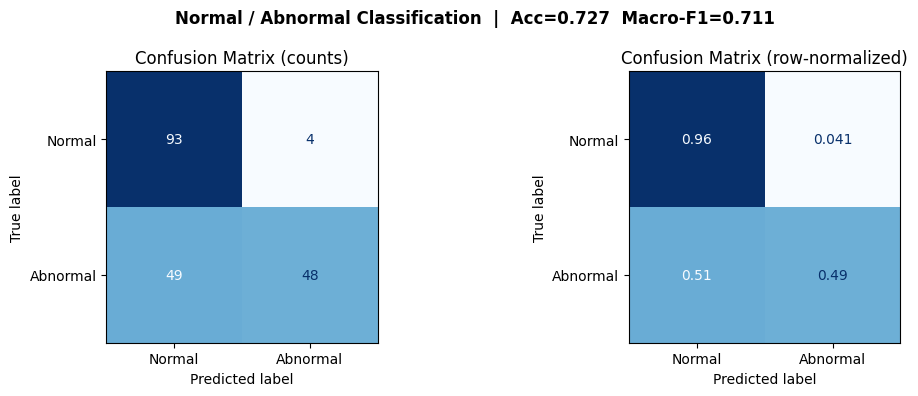


Đã lưu CM metrics → /content/drive/MyDrive/medgemma_output/eval_cm_metrics.json


In [ ]:
import re
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
    ConfusionMatrixDisplay,
)

# ─── Prerequisites ────────────────────────────────────────────────────────────
if "test_samples" not in globals():
    raise RuntimeError("Không tìm thấy `test_samples`. Hãy chạy Cell 10 trước.")
if "model" not in globals() or "processor" not in globals():
    raise RuntimeError("Không tìm thấy `model`/`processor`. Hãy chạy cell Training trước.")

# ─── Config ──────────────────────────────────────────────────────────────────
CM_N             = 200   # số mẫu tối đa; None = dùng toàn bộ
MAX_NEW_TOKENS   = 128
SEED             = 42
random.seed(SEED)
np.random.seed(SEED)

# ─── Keyword lists ───────────────────────────────────────────────────────────
_NEGATIONS = [
    "no", "without", "denies", "deny", "negative for", "free of",
    "absence of", "absent", "not",
    # thêm resolution terms
    "resolved", "resolution of", "cleared", "clearing", "no longer",
    "improved", "improvement", "stable", "unchanged",
]

_NORMAL_PATTERNS = [
    r"\bnormal (chest|study|exam|radiograph|x.?ray)\b",
    r"\bunremarkable\b",
    r"\bno acute (cardiopulmonary|pulmonary|intrathoracic) (abnormality|disease|process|finding)\b",
    r"\bno acute findings?\b",
    r"\bno active (disease|process)\b",
    r"\bwithin normal limits\b",
    r"\bno significant (abnormality|finding|change)\b",
]

_ABNORMAL_KEYWORDS = [
    "pneumonia", "consolidation", "opacity", "infiltrate", "atelectasis",
    "edema", "effusion", "pleural effusion", "pneumothorax",
    "cardiomegaly", "enlarged heart", "heart failure", "congestive",
    "fracture", "mass", "nodule", "lesion",
    "emphysema", "fibrosis", "interstitial", "airspace",
    "aspiration", "congestion", "pneumomediastinum", "subcutaneous",
]

# ─── Helper functions ─────────────────────────────────────────────────────────
def extract_impression(report_text: str) -> str:
    t = report_text or ""
    m = re.search(r"impression\s*:\s*(.*)$", t, flags=re.IGNORECASE | re.DOTALL)
    if m:
        return m.group(1).strip()
    return t.strip()

def norm_text(s: str) -> str:
    s = (s or "").lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def has_negation_near(text: str, kw: str, window: int = 6) -> bool:
    tokens = text.split()
    kw_tokens = kw.split()
    for i in range(len(tokens) - len(kw_tokens) + 1):
        if tokens[i : i + len(kw_tokens)] == kw_tokens:
            left_str = " ".join(tokens[max(0, i - window) : i])
            for neg in _NEGATIONS:
                if " " not in neg and neg in tokens[max(0, i - window) : i]:
                    return True
                if " " in neg and neg in left_str:
                    return True
    return False

def infer_label(report_text: str) -> str:
    imp = norm_text(extract_impression(report_text))
    if not imp:
        return "unknown"
    for kw in _ABNORMAL_KEYWORDS:
        kw_n = norm_text(kw)
        if kw_n and kw_n in imp and not has_negation_near(imp, kw_n):
            return "abnormal"
    for pat in _NORMAL_PATTERNS:
        if re.search(pat, imp):
            return "normal"
    return "unknown"

# ─── Stratified sample ───────────────────────────────────────────────────────
# Gán true label trước, rồi stratified sample để cân bằng
labeled_samples = []
for s in test_samples:
    lbl = infer_label(s["report"])
    if lbl != "unknown":
        labeled_samples.append((s, lbl))

normals   = [(s, l) for s, l in labeled_samples if l == "normal"]
abnormals = [(s, l) for s, l in labeled_samples if l == "abnormal"]

print(f"Ground-truth pool → normal: {len(normals)}, abnormal: {len(abnormals)}")

if CM_N is not None:
    n_each = min(CM_N // 2, len(normals), len(abnormals))
    normals   = random.sample(normals,   n_each)
    abnormals = random.sample(abnormals, n_each)

_samples = normals + abnormals
random.shuffle(_samples)
print(f"Stratified sample → {len(_samples)} mẫu ({len(normals)} normal + {len(abnormals)} abnormal)")

# ─── Generate & label predictions ────────────────────────────────────────────
model.eval()
y_true, y_pred = [], []
unknown_pred   = 0

for sample, true_lab in tqdm(_samples, desc="Generating"):
    image = Image.open(sample["image_path"]).convert("RGB")
    msgs  = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text",  "text": PROMPT},
    ]}]
    text   = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=text, images=[image], return_tensors="pt").to(model.device)

    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)

    hyp      = processor.tokenizer.decode(
        out[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True
    ).strip()
    pred_lab = infer_label(hyp)

    if pred_lab == "unknown":
        unknown_pred += 1
        # giữ lại nhưng label là "normal" (conservative) — hoặc đổi thành continue để drop
        pred_lab = "normal"

    y_true.append(1 if true_lab == "abnormal" else 0)
    y_pred.append(1 if pred_lab  == "abnormal" else 0)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ─── Metrics ─────────────────────────────────────────────────────────────────
cm                    = confusion_matrix(y_true, y_pred, labels=[0, 1])
prec, rec, f1, sup    = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1],
                                                         average=None, zero_division=0)
acc                   = accuracy_score(y_true, y_pred)
macro_f1              = f1.mean()

print(f"\nSamples used: {len(y_true)}  |  Unknown predictions (→ normal): {unknown_pred}")
print("\n" + "="*50)
print("METRICS")
print("="*50)
print(f"  Accuracy          : {acc:.4f}")
print(f"  Macro F1          : {macro_f1:.4f}")
print(f"  ─ Normal  │ P={prec[0]:.4f}  R={rec[0]:.4f}  F1={f1[0]:.4f}  n={sup[0]}")
print(f"  ─ Abnormal│ P={prec[1]:.4f}  R={rec[1]:.4f}  F1={f1[1]:.4f}  n={sup[1]}")
print("="*50)

# ─── Plot: raw + normalized confusion matrix ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels_str = ["Normal", "Abnormal"]

# Raw counts
ConfusionMatrixDisplay(cm, display_labels=labels_str).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Confusion Matrix (counts)")

# Normalized (recall / row-wise)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(np.round(cm_norm, 3), display_labels=labels_str).plot(
    ax=axes[1], colorbar=False, cmap="Blues"
)
axes[1].set_title("Confusion Matrix (row-normalized)")

fig.suptitle(
    f"Normal / Abnormal Classification  |  Acc={acc:.3f}  Macro-F1={macro_f1:.3f}",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

# ─── Lưu kết quả ─────────────────────────────────────────────────────────────
import os
cm_metrics = {
    "n_samples"      : int(len(y_true)),
    "unknown_pred"   : int(unknown_pred),
    "accuracy"       : round(float(acc), 6),
    "macro_f1"       : round(float(macro_f1), 6),
    "normal_precision" : round(float(prec[0]), 6),
    "normal_recall"    : round(float(rec[0]), 6),
    "normal_f1"        : round(float(f1[0]), 6),
    "abnormal_precision": round(float(prec[1]), 6),
    "abnormal_recall"   : round(float(rec[1]), 6),
    "abnormal_f1"       : round(float(f1[1]), 6),
    "confusion_matrix"  : cm.tolist(),
}
cm_path = os.path.join(OUTPUT_DIR, "eval_cm_metrics.json")
with open(cm_path, "w") as f:
    json.dump(cm_metrics, f, indent=2)
print(f"\nĐã lưu CM metrics → {cm_path}")


---
## Cell 11: MERGE — Gộp adapter vào model

**Bước quan trọng nhất để chạy offline.**

1. Giải phóng VRAM từ training
2. Load base model full precision
3. Merge adapter → model hoàn chỉnh
4. Lưu `merged_model/` (~8-10GB)

**Sau cell này**: Copy `merged_model/` về máy local → `output/merged_model/` → `streamlit run app.py`.

In [ ]:
import torch, gc

try:
    del model, trainer
except:
    pass
gc.collect()
torch.cuda.empty_cache()

from transformers import AutoModelForImageTextToText, AutoProcessor
from peft import PeftModel

MODEL_ID = "google/medgemma-4b-it"
OUTPUT_DIR = "/content/drive/MyDrive/medgemma_output"
adapter_dir = f"{OUTPUT_DIR}/final_adapter"
merged_dir = f"{OUTPUT_DIR}/merged_model"

print("[1/4] Loading base model (full precision)...")
base_model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

print("[2/4] Loading trained adapter...")
model = PeftModel.from_pretrained(base_model, adapter_dir)

print("[3/4] Merging...")
model = model.merge_and_unload()

print("[4/4] Saving merged model...")
model.save_pretrained(merged_dir)
proc = AutoProcessor.from_pretrained(adapter_dir)
proc.save_pretrained(merged_dir)

print(f"\nDone! Model saved to: {merged_dir}")
print("Copy thu muc nay ve may local -> output/merged_model/")
!du -sh {merged_dir}

Used samples: 200 / 200 (empty_hyp: 0)
Time: 26.81 min  (~8.04 s/sample)


,Scope,n,ref_mean,ref_median,ref_p5,ref_p95,hyp_mean,hyp_median,hyp_p5,hyp_p95,ratio_mean(hyp/ref)
0,Full report,200,39.455,36.5,17.0,74.00,31.85,24.5,19.0,56.1,0.918615
1,Impression only,200,10.165,5.0,3.0,31.05,9.16,3.0,3.0,17.0,2.474876


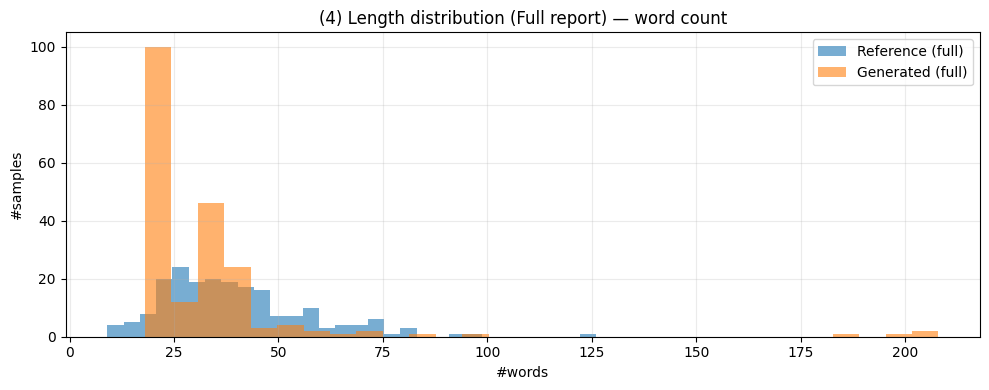

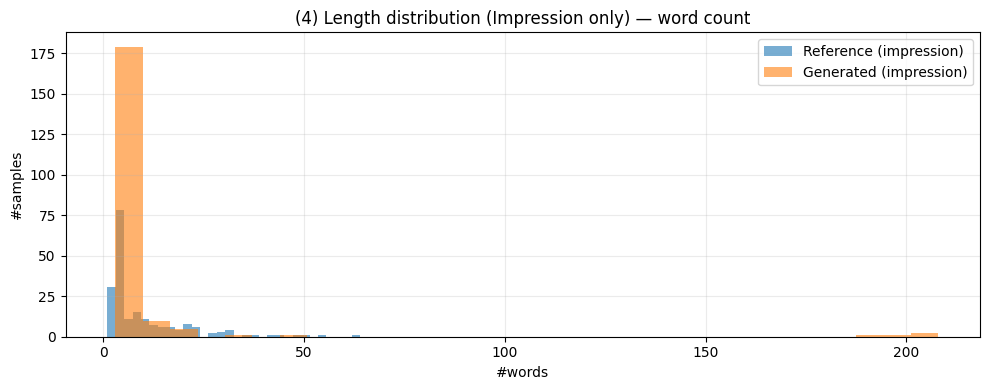

In [ ]:
import os, re, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# =============================
# Prerequisites
# =============================
if "test_samples" not in globals():
    raise RuntimeError("Không tìm thấy `test_samples`. Hãy chạy Cell 10: Đánh giá trước để tạo `test_samples`.")
if "model" not in globals() or "processor" not in globals():
    raise RuntimeError("Không tìm thấy `model`/`processor`. Hãy chạy Cell TRAINING trước (model/processor đang được dùng để eval).")
if "PROMPT" not in globals():
    raise RuntimeError("Không tìm thấy `PROMPT`. Hãy chạy Cell cấu hình trước.")

# =============================
# Config
# =============================
LEN_N = 200  # số mẫu để đo độ dài (tăng/giảm tuỳ thời gian)
MAX_NEW_TOKENS_LEN = 256
SEED = 42

random.seed(SEED)
_samples = test_samples
if len(_samples) > LEN_N:
    _samples = random.sample(_samples, LEN_N)

# =============================
# Helpers
# =============================
_IMP_RE = re.compile(r"impression\s*:\s*(.*)$", flags=re.IGNORECASE | re.DOTALL)

def extract_impression(text: str) -> str:
    t = (text or "").strip()
    m = _IMP_RE.search(t)
    if m:
        return (m.group(1) or "").strip()
    # fallback: nếu không có marker rõ
    return t

def word_count(s: str) -> int:
    s = (s or "").strip()
    if not s:
        return 0
    # tách từ đơn giản (ổn cho bảng thống kê)
    return len(re.findall(r"\b\w+\b", s))

def pct(arr, p):
    if len(arr) == 0:
        return float("nan")
    return float(np.percentile(arr, p))

# =============================
# Generate subset + collect lengths
# =============================
model.eval()

ref_len_full, hyp_len_full = [], []
ref_len_imp,  hyp_len_imp  = [], []
empty_hyp = 0

# (tuỳ chọn) đo thời gian sinh để ước lượng
_t0 = time.perf_counter()
for sample in _samples:
    ref = sample["report"]

    try:
        image = Image.open(sample["image_path"]).convert("RGB")
    except Exception:
        continue

    msgs = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text",  "text": PROMPT},
    ]}]
    text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=text, images=[image], return_tensors="pt").to(model.device)

    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS_LEN, do_sample=False)

    hyp = processor.tokenizer.decode(
        out[0, inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    ).strip()

    if not hyp:
        empty_hyp += 1
        continue

    # full
    ref_len_full.append(word_count(ref))
    hyp_len_full.append(word_count(hyp))

    # impression-only
    ref_imp = extract_impression(ref)
    hyp_imp = extract_impression(hyp)
    ref_len_imp.append(word_count(ref_imp))
    hyp_len_imp.append(word_count(hyp_imp))

_dt = time.perf_counter() - _t0

if len(ref_len_full) == 0:
    raise RuntimeError("Không thu được mẫu hợp lệ để thống kê độ dài (có thể do lỗi đọc ảnh hoặc output rỗng).")

# =============================
# Table (summary statistics)
# =============================
rows = []
for name, ref_arr, hyp_arr in [
    ("Full report", np.array(ref_len_full), np.array(hyp_len_full)),
    ("Impression only", np.array(ref_len_imp),  np.array(hyp_len_imp)),
]:
    rows.append({
        "Scope": name,
        "n": int(len(ref_arr)),
        "ref_mean": float(np.mean(ref_arr)),
        "ref_median": float(np.median(ref_arr)),
        "ref_p5": pct(ref_arr, 5),
        "ref_p95": pct(ref_arr, 95),
        "hyp_mean": float(np.mean(hyp_arr)),
        "hyp_median": float(np.median(hyp_arr)),
        "hyp_p5": pct(hyp_arr, 5),
        "hyp_p95": pct(hyp_arr, 95),
        "ratio_mean(hyp/ref)": float(np.mean(hyp_arr / np.maximum(ref_arr, 1))),
    })

df_len = pd.DataFrame(rows)
print(f"Used samples: {len(ref_len_full)} / {len(_samples)} (empty_hyp: {empty_hyp})")
print(f"Time: {_dt/60:.2f} min  (~{_dt/max(1,len(ref_len_full)):.2f} s/sample)")
display(df_len)

# =============================
# Plots
# =============================
plt.figure(figsize=(10, 4))
plt.hist(ref_len_full, bins=30, alpha=0.6, label="Reference (full)")
plt.hist(hyp_len_full, bins=30, alpha=0.6, label="Generated (full)")
plt.title("(4) Length distribution (Full report) — word count")
plt.xlabel("#words")
plt.ylabel("#samples")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(ref_len_imp, bins=30, alpha=0.6, label="Reference (impression)")
plt.hist(hyp_len_imp, bins=30, alpha=0.6, label="Generated (impression)")
plt.title("(4) Length distribution (Impression only) — word count")
plt.xlabel("#words")
plt.ylabel("#samples")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

---
## Cell 12: Test inference

Load merged model, chạy 1 ảnh test, so sánh báo cáo sinh ra với báo cáo gốc.

In [ ]:
import torch, json
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

OUTPUT_DIR = "/content/drive/MyDrive/medgemma_output"
merged_dir = f"{OUTPUT_DIR}/merged_model"
PROCESSED_DIR = "/content/drive/MyDrive/iu_xray_data/processed"
PROMPT = "Describe the findings in this chest X-ray image and provide a clinical impression."

print("Loading merged model (4-bit)...")
proc = AutoProcessor.from_pretrained(merged_dir, trust_remote_code=True)
mdl = AutoModelForImageTextToText.from_pretrained(
    merged_dir,
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True),
    device_map="auto", torch_dtype=torch.float16, trust_remote_code=True,
)
mdl.eval()

with open(f"{PROCESSED_DIR}/test.jsonl") as f:
    sample = json.loads(f.readline())

image = Image.open(sample["image_path"]).convert("RGB")
display(image.resize((384, 384)))

msgs = [{"role": "user", "content": [
    {"type": "image", "image": image},
    {"type": "text", "text": PROMPT}]}]
text = proc.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
inputs = proc(text=text, images=[image], return_tensors="pt").to(mdl.device)

with torch.no_grad():
    out = mdl.generate(**inputs, max_new_tokens=256, do_sample=False)
result = proc.tokenizer.decode(out[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True)

print("=" * 50)
print("BAO CAO SINH TU DONG:")
print("=" * 50)
print(result.strip())
print("\n" + "=" * 50)
print("BAO CAO GOC (Ground Truth):")
print("=" * 50)
print(sample["report"])